# Sensitivity Analysis of models created by model.ipynb

In this notebook, first the model created by model.ipynb is imported and then the sensitivity analysis is implemented.

## importing requried packages

In [1]:
import linopy
import pypsa

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

import cartopy
import cartopy.crs as ccrs

import networkx as nx

import atlite
from atlite.gis import ExclusionContainer, shape_availability
from rasterio.plot import show
from rasterio.crs import CRS
import rasterio as rio

from pathlib import Path
import xarray as xr

## Importing the models

In [2]:
#n = pypsa.Network("pypsa_model_n.nc") # the model without CO2 limitations
n = pypsa.Network("pypsa_model_n_no_co2.nc") # the model with CO2 limitation of 0

INFO:pypsa.network.io:New version 1.0.7 available! (Current: 1.0.5)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, links, loads, storage_units, sub_networks


In [3]:
n.storage_units

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,...,state_of_charge_initial_per_period,state_of_charge_set,cyclic_state_of_charge,cyclic_state_of_charge_per_period,max_hours,efficiency_store,efficiency_dispatch,standing_loss,inflow,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
battery_2h_Alborz,Alborz,PQ,,0.0,0.0,True,0.0,inf,NaN,-1.0,...,False,NaN,True,False,2.0,0.9550,0.955,0.0,0.0,0.090100
battery_4h_Alborz,Alborz,PQ,,0.0,0.0,True,0.0,inf,NaN,-1.0,...,False,NaN,True,False,4.0,0.9550,0.955,0.0,0.0,0.340197
battery_6h_Alborz,Alborz,PQ,,0.0,0.0,True,0.0,inf,NaN,-1.0,...,False,NaN,True,False,6.0,0.9550,0.955,0.0,0.0,453.228072
battery_2h_Ardabil,Ardabil,PQ,,0.0,0.0,True,0.0,inf,NaN,-1.0,...,False,NaN,True,False,2.0,0.9550,0.955,0.0,0.0,0.080865
battery_4h_Ardabil,Ardabil,PQ,,0.0,0.0,True,0.0,inf,NaN,-1.0,...,False,NaN,True,False,4.0,0.9550,0.955,0.0,0.0,0.133009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
h2_336h_Yazd,Yazd,PQ,,0.0,0.0,True,0.0,inf,NaN,-1.0,...,False,NaN,True,False,336.0,0.5874,0.500,0.0,0.0,0.113636
h2_672h_Yazd,Yazd,PQ,,0.0,0.0,True,0.0,inf,NaN,-1.0,...,False,NaN,True,False,672.0,0.5874,0.500,0.0,0.0,5.732121
h2_168h_Zanjan,Zanjan,PQ,,0.0,0.0,True,0.0,inf,NaN,-1.0,...,False,NaN,True,False,168.0,0.5874,0.500,0.0,0.0,0.022665


In [4]:
n.statistics.energy_balance.iplot()

In [5]:
#n.generators.loc[n.generators.carrier == "solar", "capital_cost"]
n.storage_units.loc[n.storage_units.carrier == "battery storage", "capital_cost"]

name
battery_2h_Alborz      68736.356602
battery_4h_Alborz     104346.481305
battery_6h_Alborz     139956.606008
battery_2h_Ardabil     68736.356602
battery_4h_Ardabil    104346.481305
                          ...      
battery_4h_Yazd       104346.481305
battery_6h_Yazd       139956.606008
battery_2h_Zanjan      68736.356602
battery_4h_Zanjan     104346.481305
battery_6h_Zanjan     139956.606008
Name: capital_cost, Length: 93, dtype: float64

In [6]:
# =============================================================================
# Sensitivity Analysis: Technology Cost Variation
# =============================================================================

# 1. Define cost reduction factors
# 1.0 = Original Price, 0.75 = 25% reduction, etc.
cost_factors = [1.0, 0.75, 0.5, 0.25, 0.0]

# 2. Select the technology to analyze
tech_name = "onwind"  # Change to "solar", "onwind", etc. as needed

# a dictionary to store results
results = {}

# 3. Backup original capital costs to avoid permanent modification during the loop
# Check if the technology is a generator or a storage unit
if tech_name in n.storage_units.carrier.values:
    original_cost = n.storage_units.loc[n.storage_units.carrier == tech_name, "capital_cost"].copy()
    is_storage = True
    print(f"Starting sensitivity analysis for Storage Technology: {tech_name}")
else:
    original_cost = n.generators.loc[n.generators.carrier == tech_name, "capital_cost"].copy()
    is_storage = False
    print(f"Starting sensitivity analysis for Generation Technology: {tech_name}")

# 4. Iterate through cost factors
for factor in cost_factors:
    print(f"Processing: Cost Factor = {factor} ...")
    
    # Update Capital Costs 
    if is_storage:
        n.storage_units.loc[n.storage_units.carrier == tech_name, "capital_cost"] = original_cost * factor
    else:
        n.generators.loc[n.generators.carrier == tech_name, "capital_cost"] = original_cost * factor
     
    # solve the model with co2 limit
    n.optimize(
        #snapshots=n_no_co2.snapshots[:168],  # 1 week
        solver_name="gurobi",
        method=2,
        crossover=0,
        BarConvTol=1.0e-05,
        AggFill=0,
        PreDual=0,
        GURO_PAR_BARDENSETHRESH=200,
        log_to_console=False
    )
    
    # Record Results 
    # Aggregate optimal capacities (p_nom_opt) by carrier
    gen_cap = n.generators.groupby("carrier").p_nom_opt.sum()
    store_cap = n.storage_units.groupby("carrier").p_nom_opt.sum()
    
    # Combine generation and storage capacities
    total_cap = pd.concat([gen_cap, store_cap])
    results[factor] = total_cap

print("Analysis complete.")

Starting sensitivity analysis for Generation Technology: onwind
Processing: Cost Factor = 1.0 ...


INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - method: 2
 - crossover: 0
 - BarConvTol: 1e-05
 - AggFill: 0
 - PreDual: 0
 - GURO_PAR_BARDENSETHRESH: 200
 - log_to_console: False
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 8/8 [00:00<00:00, 47.82it/s]
INFO:linopy.io: Writing time: 3.91s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2750042


...

Set parameter GURO_PAR_BARDENSETHRESH to value 200


INFO:gurobipy:Set parameter GURO_PAR_BARDENSETHRESH to value 200


Set parameter LogToConsole to value 0


INFO:gurobipy:Set parameter LogToConsole to value 0
INFO:gurobipy:Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (mac64[arm] - Darwin 25.2.0 25C56)
INFO:gurobipy:
INFO:gurobipy:CPU model: Apple M4 Pro
INFO:gurobipy:Thread count: 14 physical cores, 14 logical processors, using up to 14 threads
INFO:gurobipy:
INFO:gurobipy:Non-default parameters:
INFO:gurobipy:Method  2
INFO:gurobipy:BarConvTol  1e-05
INFO:gurobipy:Crossover  0
INFO:gurobipy:AggFill  0
INFO:gurobipy:PreDual  0
INFO:gurobipy:LogToConsole  0
INFO:gurobipy:GURO_PAR_BARDENSETHRESH  200
INFO:gurobipy:
INFO:gurobipy:Optimize a model with 5037396 rows, 2199091 columns and 10827366 nonzeros (Min)
INFO:gurobipy:Model fingerprint: 0x23869a24
INFO:gurobipy:Model has 303980 linear objective coefficients
INFO:gurobipy:Coefficient statistics:
INFO:gurobipy:  Matrix range     [2e-10, 7e+02]
INFO:gurobipy:  Objective range  [3e-02, 6e+05]
INFO:gurobipy:  Bounds range     [0e+00, 0e+00]
INFO:gurobipy:  RHS range        [2e+00, 4e+05]
I

Analysis complete.


In [7]:
"""# importing the results from csv
url = Path("results") / "sens_analysis_onwind_results.csv"
tech_name = "onwind"
df_results = pd.read_csv(url, index_col=0)
df_results"""

'# importing the results from csv\nurl = Path("results") / "sens_analysis_onwind_results.csv"\ntech_name = "onwind"\ndf_results = pd.read_csv(url, index_col=0)\ndf_results'

In [8]:
# saving the results in a DataFrame
df_results = pd.DataFrame(results)
#df_results_re = df_results.loc[["offwind", "onwind", "solar", "battery storage", "hydrogen storage underground"], :]

In [9]:
# saving the results as a csv in results folder
df_results.to_csv("results/sens_analysis_onwind_results.csv")

In [10]:
"""# importing the results from csv
url = Path("results") / "sens_analysis_onwind_results.csv"
df_results = pd.read_csv(url, index_col=0)
df_results"""

'# importing the results from csv\nurl = Path("results") / "sens_analysis_onwind_results.csv"\ndf_results = pd.read_csv(url, index_col=0)\ndf_results'

In [11]:
df_results_re = df_results.loc[["offwind", "onwind", "solar", "battery storage", "hydrogen storage underground"], :]

In [12]:
df_results_re.divide(1e3)

,1.00,0.75,0.50,0.25,0.00
carrier,,,,,
offwind,0.000085,0.000359,0.000167,0.000054,0.000006
onwind,21.986125,44.063436,58.820263,151.602633,2259.748820
solar,237.916868,217.105903,209.717368,184.186671,63.542547
battery storage,95.116007,94.098546,93.372469,88.163547,44.091771
hydrogen storage underground,7.932360,5.668554,5.105878,5.075429,15.060491


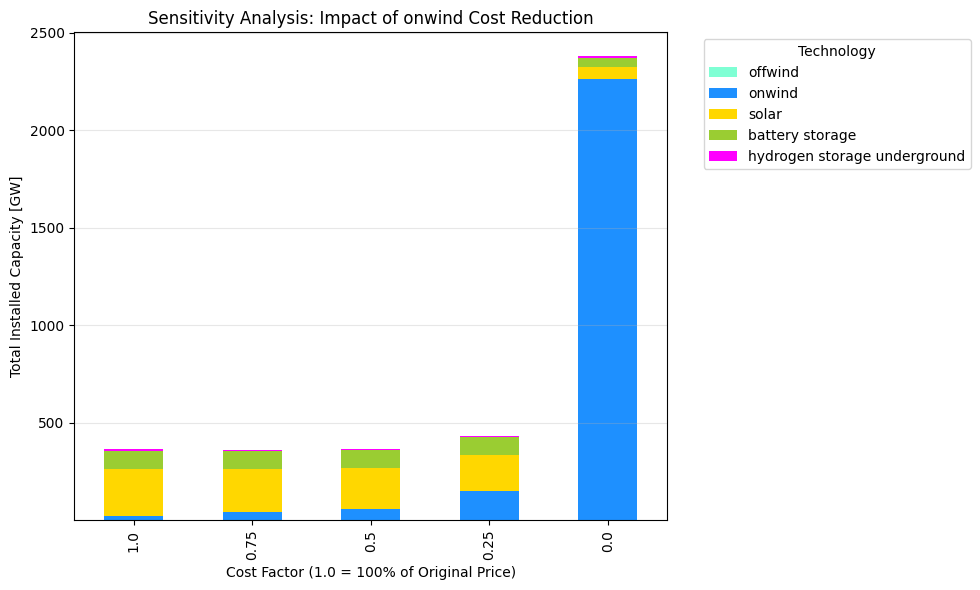

In [13]:
# Data to plot
df_plot = df_results_re.divide(1e3).T

# Align colors with columns (technologies / carriers)
colors = n.carriers.color.reindex(df_plot.columns)

fig, ax = plt.subplots(figsize=(10, 6))

df_plot.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors
)

plt.title(f"Sensitivity Analysis: Impact of {tech_name} Cost Reduction")
plt.xlabel("Cost Factor (1.0 = 100% of Original Price)")
plt.ylabel("Total Installed Capacity [GW]")

plt.legend(
    title="Technology",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


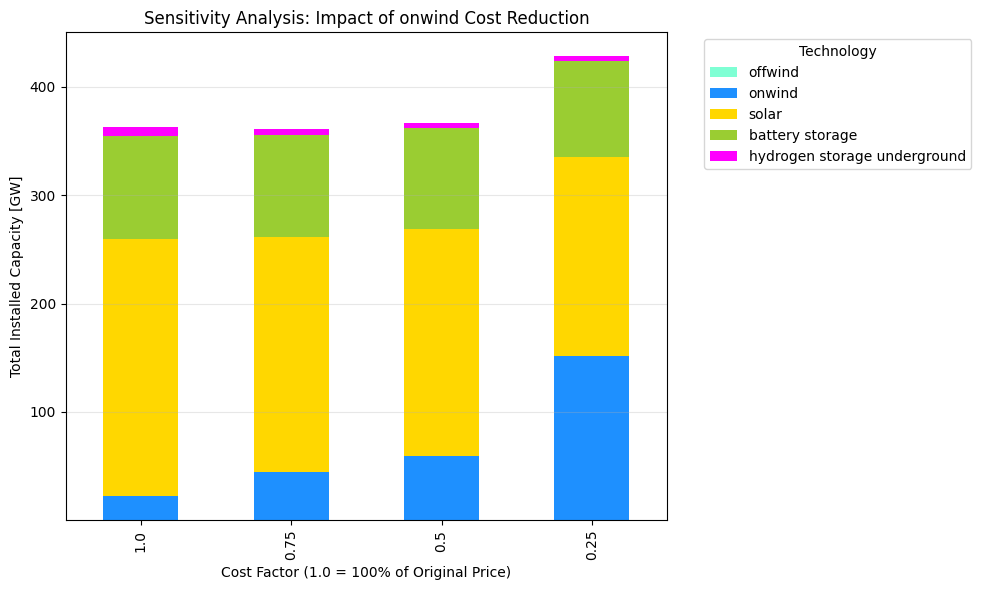

In [14]:
results_withoud_0_battery_cost = df_results_re.iloc[:, :-1]

# Data to plot
df_plot = results_withoud_0_battery_cost.divide(1e3).T

# Align colors with columns (technologies / carriers)
colors = n.carriers.color.reindex(df_plot.columns)

fig, ax = plt.subplots(figsize=(10, 6))

df_plot.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors
)

plt.title(f"Sensitivity Analysis: Impact of {tech_name} Cost Reduction")
plt.xlabel("Cost Factor (1.0 = 100% of Original Price)")
plt.ylabel("Total Installed Capacity [GW]")

plt.legend(
    title="Technology",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()